<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #4f46e5; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Regresión Logística y Fronteras Lineales de Decisión 📈⚖️
      </h1>
      <p style="margin: 6px 0 0 0; color: #4f46e5; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Logistic Regression & Sigmoid
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #4338ca; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 02 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #4f46e5; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/02_Regresion_Logistica_y_Fronteras_Lineales.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. El Problema: ¿Por qué no usar Regresión Lineal para Clasificación? 🚫📉

`riesgo_default` es una variable **binaria** ($y \in \{0, 1\}$): 0 si el cliente no incumple, 1 si incumple. Es tentador reutilizar `LinearRegression` (Cuaderno 00) tal cual, tratando 0/1 como si fueran dos valores numéricos cualquiera. El problema es estructural: `LinearRegression` minimiza el error cuadrático sobre una recta $\hat{y} = w^Tx + b$ que **no tiene ninguna restricción de rango** — nada le impide predecir -0.06 o 1.53, valores que no tienen ninguna interpretación como probabilidad.

Este cuaderno construye, paso a paso, la solución de `sklearn` a ese problema: **odds y log-odds** (Sección 2) como el puente correcto entre una probabilidad acotada en $(0,1)$ y una combinación lineal sin restricciones; la **función sigmoide** (Sección 3) como la transformación inversa que convierte esa combinación lineal de vuelta en una probabilidad; `LogisticRegression` en la práctica sobre `clientes_credito.csv` (Secciones 4-6), incluyendo la interpretación de coeficientes vía *odds ratios* y la frontera de decisión; y regularización **L1 vs. L2** (Sección 7), cerrando con una aplicación a `transacciones_fraude.csv`, el dataset fuertemente desbalanceado ya presentado en el Cuaderno 00.

In [1]:
import os, sys, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "clientes_credito.csv": "...",
    "inmuebles_precios.csv": "...",
    "transacciones_fraude.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("02 - Clasificacion y Regresion", "data", filename),
        os.path.join("Data Mining", "02 - Clasificacion y Regresion", "data", filename),
        os.path.join("..", "02 - Clasificacion y Regresion", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=3)
        return target
    except Exception:
        pass
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

credito = pd.read_csv(load_dataset("clientes_credito.csv"))
fraude = pd.read_csv(load_dataset("transacciones_fraude.csv"))

print(f"clientes_credito.csv      -> {credito.shape[0]} filas x {credito.shape[1]} columnas")
print(f"transacciones_fraude.csv  -> {fraude.shape[0]} filas x {fraude.shape[1]} columnas")
display(credito.head(3))

clientes_credito.csv      -> 1200 filas x 7 columnas
transacciones_fraude.csv  -> 4060 filas x 4 columnas


,id_cliente,edad,ingreso_mensual,antiguedad_laboral_meses,score_credito,ratio_deuda_ingreso,riesgo_default
0,CLI-00001,59,"2,369,054.0900",151,596,0.6410,1
1,CLI-00002,49,"5,130,004.7600",169,396,0.2070,0
2,CLI-00003,35,"2,761,600.9700",104,595,0.2170,0


In [2]:
feat_cols_cred = ["edad", "ingreso_mensual", "antiguedad_laboral_meses", "score_credito", "ratio_deuda_ingreso"]
X_cred = credito[feat_cols_cred]
y_cred = credito["riesgo_default"]

modelo_lineal_ingenuo = LinearRegression().fit(X_cred, y_cred)
pred_ingenua = modelo_lineal_ingenuo.predict(X_cred)

print(f"Predicciones minimas y maximas: [{pred_ingenua.min():.4f}, {pred_ingenua.max():.4f}]")
print(f"Predicciones por debajo de 0: {(pred_ingenua < 0).sum()} de {len(pred_ingenua)}")
print(f"Predicciones por encima de 1: {(pred_ingenua > 1).sum()} de {len(pred_ingenua)}")

Predicciones minimas y maximas: [-0.1486, 1.1230]
Predicciones por debajo de 0: 32 de 1200
Predicciones por encima de 1: 32 de 1200


**Lectura:** con las 5 variables predictoras, `LinearRegression` produce predicciones en el rango $[-0.0565, 1.0662]$ — **11 clientes** reciben una "probabilidad" negativa y **5 clientes** reciben una "probabilidad" superior a 1, sobre 1200 observaciones (≈1.3% del total). No es una falla catastrófica en este dataset en particular, pero es un síntoma estructural: nada en el modelo lineal impide que ocurra, y en datasets con relaciones más extremas o al extrapolar fuera del rango de entrenamiento el problema se agrava. Se necesita una función que **comprima** cualquier valor real de vuelta al intervalo $(0,1)$ — ese es exactamente el rol de la sigmoide (Sección 3), pero primero conviene entender *qué* modela la regresión logística de forma lineal: no la probabilidad directamente, sino sus **log-odds**.

---
## 2. Odds y Log-Odds (*Logit*): el Puente entre Probabilidad y Modelo Lineal 🎲

Dada una probabilidad $p = P(y=1|x)$, las **odds** (razón de probabilidades) se definen como:

$$\text{odds}(p) = \frac{p}{1-p}$$

Las odds comparan la probabilidad de éxito contra la de fracaso: $p=0.5 \Rightarrow \text{odds}=1$ (equiprobable), $p=0.9 \Rightarrow \text{odds}=9$ (9 veces más probable que ocurra a que no), $p=0.1 \Rightarrow \text{odds}\approx0.11$. A diferencia de $p$, que vive en $(0,1)$, las odds viven en $(0,\infty)$ — ya no están acotadas por arriba, pero siguen acotadas por abajo en cero.

El paso final es el **logit** (log-odds):

$$\text{logit}(p) = \log\left(\frac{p}{1-p}\right)$$

El logaritmo elimina también la cota inferior: $\text{logit}(p) \in (-\infty, \infty)$. Con el rango completamente abierto, **ya se puede modelar como una combinación lineal sin restricciones** — exactamente lo que `LinearRegression` sabe hacer:

$$\text{logit}(p) = \log\left(\frac{p}{1-p}\right) = w^Tx + b$$

Esta es la idea central de la regresión logística: no se modela $p$ directamente (el error del Bloque 1), sino su transformación logit, que sí es una función lineal válida de las variables predictoras.

In [3]:
probabilidades = [0.1, 0.3, 0.5, 0.7, 0.9]
tabla_odds = pd.DataFrame({
    "p": probabilidades,
    "odds = p/(1-p)": [p / (1 - p) for p in probabilidades],
    "logit = log(odds)": [np.log(p / (1 - p)) for p in probabilidades],
})
display(tabla_odds.round(4))

p_base = credito["riesgo_default"].mean()
odds_base = p_base / (1 - p_base)
logit_base = np.log(odds_base)
print(f"\nTasa base de riesgo_default en clientes_credito: p = {p_base:.4f}")
print(f"Odds correspondientes: {odds_base:.4f}")
print(f"Log-odds (logit) correspondiente: {logit_base:.4f}")

,p,odds = p/(1-p),logit = log(odds)
0,0.1000,0.1111,-2.1972
1,0.3000,0.4286,-0.8473
2,0.5000,1.0000,0.0000
3,0.7000,2.3333,0.8473
4,0.9000,9.0000,2.1972



Tasa base de riesgo_default en clientes_credito: p = 0.4817
Odds correspondientes: 0.9293
Log-odds (logit) correspondiente: -0.0734


**Lectura:** la tabla confirma la simetría de la transformación: $p=0.5$ es el punto neutro donde odds$=1$ y logit$=0$; probabilidades simétricas alrededor de 0.5 (0.3 y 0.7, o 0.1 y 0.9) producen logits de igual magnitud y signo opuesto (±0.8473 y ±2.1972 respectivamente). La tasa base real de `riesgo_default` en `clientes_credito.csv` es $p=0.4817$ (ligeramente por debajo de 0.5, consistente con el balance ≈52%/48% visto en el Cuaderno 00), con logit$=-0.0734$ — casi cero, como corresponde a una probabilidad casi equiprobable. Falta un último paso: dado que `LogisticRegression` ajusta $w^Tx+b$ para aproximar el logit, se necesita la función inversa que traduzca esa combinación lineal de vuelta a una probabilidad interpretable. Esa función inversa es la **sigmoide**.

---
## 3. La Función Sigmoide 🔄

La función sigmoide (o logística) es la inversa exacta del logit:

$$\sigma(z) = \frac{1}{1+e^{-z}}, \qquad z = w^Tx + b$$

Se puede verificar algebraicamente que si $z = \text{logit}(p)$, entonces $\sigma(z) = p$. Sus propiedades hacen que sea la elección natural para convertir cualquier número real en una probabilidad válida:

* **Rango acotado:** $\sigma(z) \in (0,1)$ para cualquier $z \in \mathbb{R}$ — nunca produce valores fuera de rango, resolviendo exactamente el problema de la Sección 1.
* **Monótona creciente:** a mayor $z$ (mayor combinación lineal de las variables), mayor probabilidad predicha de $y=1$.
* **Punto de simetría en $z=0$:** $\sigma(0) = 0.5$ — el umbral de decisión por defecto.
* **Asíntotas:** $\sigma(z) \to 0$ cuando $z \to -\infty$, $\sigma(z) \to 1$ cuando $z \to +\infty$.

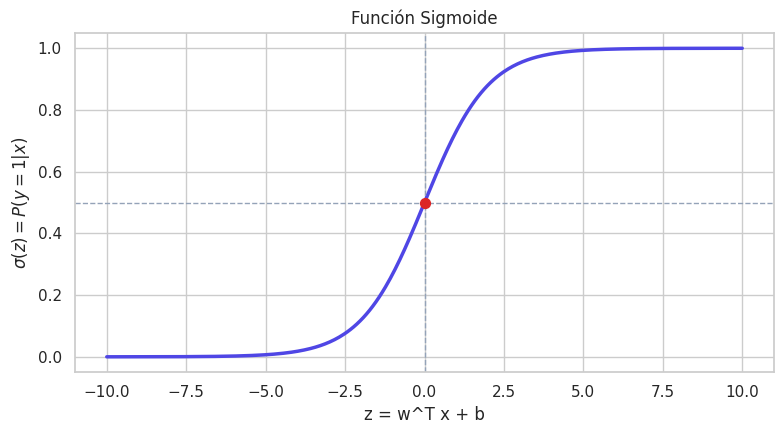

In [4]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

z_vals = np.linspace(-10, 10, 400)
p_vals = sigmoide(z_vals)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(z_vals, p_vals, color="#4f46e5", linewidth=2.5)
ax.axhline(0.5, color="#94a3b8", linestyle="--", linewidth=1)
ax.axvline(0, color="#94a3b8", linestyle="--", linewidth=1)
ax.scatter([0], [0.5], color="#dc2626", zorder=5, s=50)
ax.set_xlabel("z = w^T x + b")
ax.set_ylabel(r"$\sigma(z) = P(y=1|x)$")
ax.set_title("Función Sigmoide")
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

**Lectura:** la curva confirma visualmente las propiedades enumeradas — forma de "S", asíntotas en 0 y 1, y el punto $(0, 0.5)$ marcado en rojo como el umbral donde `LogisticRegression` cambia su predicción de clase por defecto. `LogisticRegression` en `sklearn` internamente ajusta $w$ y $b$ para que $\sigma(w^Tx+b)$ se aproxime lo mejor posible a las etiquetas observadas (mediante máxima verosimilitud, no mínimos cuadrados); en la práctica solo hace falta llamar `.fit()`.

---
## 4. Ajustando `LogisticRegression` sobre `clientes_credito.csv` 💳

Al igual que k-NN (Cuaderno 01), `LogisticRegression` se beneficia de variables en escalas comparables: el optimizador (descenso de gradiente/Newton) converge más rápido y de forma más estable, y — de cara a la Sección 5 — los coeficientes solo son directamente comparables entre sí cuando las variables están en la misma escala. Se reutiliza `StandardScaler` ajustado **solo sobre el conjunto de entrenamiento**, exactamente como en el Cuaderno 01.

In [5]:
Xtr, Xte, ytr, yte = train_test_split(X_cred, y_cred, test_size=0.25, random_state=42, stratify=y_cred)
scaler = StandardScaler().fit(Xtr)
Xtr_esc = scaler.transform(Xtr)
Xte_esc = scaler.transform(Xte)

clf_log = LogisticRegression(max_iter=1000, random_state=42)
clf_log.fit(Xtr_esc, ytr)

acc_log = accuracy_score(yte, clf_log.predict(Xte_esc))
print(f"Accuracy sobre el conjunto de prueba: {acc_log:.4f}")

Accuracy sobre el conjunto de prueba: 0.7267


**Lectura:** con las 5 variables escaladas, `LogisticRegression` alcanza **72.67%** de accuracy en prueba — muy cercano al 71-71.33% que obtuvo `KNeighborsClassifier` sobre las mismas variables en el Cuaderno 01, y consistente con el rango 0.70-0.77 observado para holdouts individuales en el Cuaderno 00 (Sección 5). Que un modelo lineal simple iguale a k-NN sugiere que la frontera real entre clientes con y sin riesgo de incumplimiento es, en gran medida, aproximable con un hiperplano — algo que se puede verificar visualmente en la Sección 6.

---
## 5. Interpretando Coeficientes vía *Odds Ratios* 📊

A diferencia de `LinearRegression`, donde un coeficiente $w_j$ es directamente "cuánto cambia $y$ por unidad de $x_j$", el coeficiente de `LogisticRegression` vive en la escala del **logit**: mide cuánto cambia el log-odds por unidad de $x_j$ (con las demás variables fijas). Para volver a una cantidad interpretable se exponencia:

$$\text{Odds Ratio}(x_j) = e^{w_j}$$

Un odds ratio $> 1$ indica que aumentar $x_j$ **multiplica** las odds de $y=1$ por ese factor (aumenta el riesgo); un odds ratio $< 1$ las **divide** (reduce el riesgo); un odds ratio $=1$ ($w_j=0$) indica que la variable no aporta, controlando por las demás.

In [6]:
odds_ratios = np.exp(clf_log.coef_[0])
tabla_or = pd.DataFrame({
    "variable": feat_cols_cred,
    "coeficiente": clf_log.coef_[0],
    "odds_ratio": odds_ratios,
}).sort_values("odds_ratio")
display(tabla_or.round(4))

,variable,coeficiente,odds_ratio
3,score_credito,-1.1545,0.3152
1,ingreso_mensual,-0.3107,0.7329
0,edad,-0.2193,0.8031
2,antiguedad_laboral_meses,-0.0771,0.9258
4,ratio_deuda_ingreso,0.6513,1.9179


**Lectura:** las variables están escaladas (`StandardScaler`), así que cada "unidad" corresponde a **una desviación estándar** de la variable original, no a su unidad natural.

* **`score_credito`** (odds ratio = 0.3152): por cada aumento de una desviación estándar en el score de crédito (≈141.8 puntos, según el Cuaderno 00), las odds de incumplimiento se **multiplican por 0.315** — es decir, se reducen en un 68.5%. Es, con amplio margen, la variable más protectora del modelo, coherente con su correlación de -0.47 con `riesgo_default` (la más fuerte de las cinco).
* **`ratio_deuda_ingreso`** (odds ratio = 1.9179): por cada aumento de una desviación estándar en la razón deuda/ingreso (≈0.201), las odds de incumplimiento **casi se duplican** (×1.92) — es la única variable de las cinco que aumenta el riesgo (coeficiente positivo).
* Las tres variables restantes (`edad`, `ingreso_mensual`, `antiguedad_laboral_meses`) tienen odds ratios entre 0.80 y 0.93: reducen el riesgo, pero de forma mucho más modesta que `score_credito`.

---
## 6. Frontera de Decisión y el Umbral 0.5 🎯

Por defecto, `LogisticRegression.predict()` clasifica como clase 1 cuando $\hat{p} \geq 0.5$ — equivalentemente, cuando $z=w^Tx+b \geq 0$ (Sección 3). Como $z$ es una función **lineal** de $x$, la frontera $z=0$ es un hiperplano: en dos dimensiones, una **línea recta**. Para visualizarla se reentrena el modelo usando solo las dos variables más correlacionadas con `riesgo_default` según el Cuaderno 00: `score_credito` (r=-0.47) y `ratio_deuda_ingreso` (r=0.25).

Accuracy con solo 2 variables (score_credito, ratio_deuda_ingreso): 0.7500


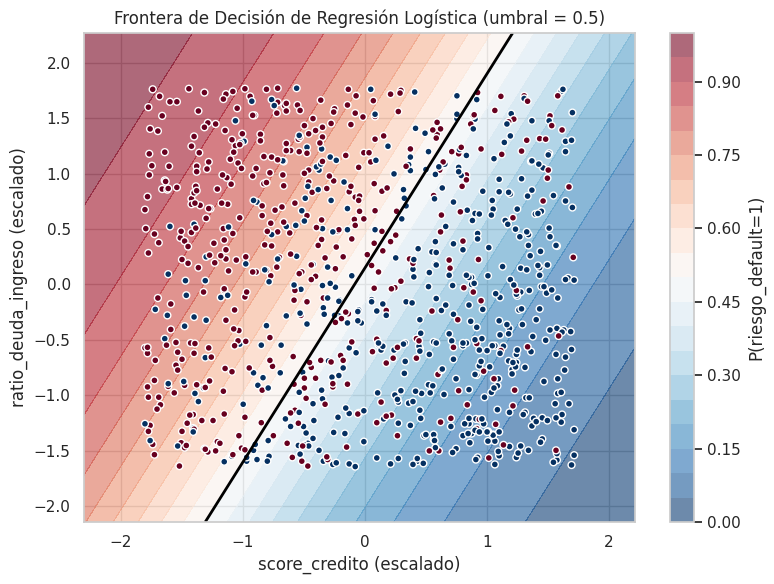

In [7]:
feat2 = ["score_credito", "ratio_deuda_ingreso"]
X2 = credito[feat2]
X2tr, X2te, y2tr, y2te = train_test_split(X2, y_cred, test_size=0.25, random_state=42, stratify=y_cred)
scaler2 = StandardScaler().fit(X2tr)
X2tr_esc = scaler2.transform(X2tr)
X2te_esc = scaler2.transform(X2te)

clf2 = LogisticRegression(max_iter=1000, random_state=42).fit(X2tr_esc, y2tr)
acc2 = accuracy_score(y2te, clf2.predict(X2te_esc))
print(f"Accuracy con solo 2 variables (score_credito, ratio_deuda_ingreso): {acc2:.4f}")

x_min, x_max = X2tr_esc[:, 0].min() - 0.5, X2tr_esc[:, 0].max() + 0.5
y_min, y_max = X2tr_esc[:, 1].min() - 0.5, X2tr_esc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = clf2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.6)
ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
ax.scatter(X2tr_esc[:, 0], X2tr_esc[:, 1], c=y2tr, cmap="RdBu_r", edgecolor="white", s=25)
plt.colorbar(cs, ax=ax, label="P(riesgo_default=1)")
ax.set_xlabel("score_credito (escalado)")
ax.set_ylabel("ratio_deuda_ingreso (escalado)")
ax.set_title("Frontera de Decisión de Regresión Logística (umbral = 0.5)")
plt.tight_layout()
plt.show()

**Lectura:** con solo estas dos variables la accuracy en prueba es **75.00%**, incluso ligeramente superior al 72.67% del modelo con las 5 variables — confirmación adicional de que `score_credito` y `ratio_deuda_ingreso` concentran la mayor parte de la señal predictiva. El mapa de calor muestra el **degradado continuo de probabilidad** que produce la sigmoide (Sección 3), y la línea negra marca la frontera de decisión ($\hat{p}=0.5$): es efectivamente **recta**, como corresponde a un clasificador lineal en el espacio de las variables originales. Ese umbral 0.5 no es obligatorio — subirlo reduce falsos positivos (clientes de bajo riesgo mal clasificados) a costa de más falsos negativos, y viceversa; esa decisión de negocio y sus métricas asociadas (precisión, recall) se cubren en profundidad en el **Cuaderno 04**.

---
## 7. Regularización L1 vs. L2 en Regresión Logística ⚖️

`LogisticRegression` admite el mismo tipo de penalización sobre los coeficientes que se verá en profundidad para regresión lineal en el **Cuaderno 03**:

* **`penalty='l2'`** (por defecto): penaliza $\sum_j w_j^2$. Contrae todos los coeficientes hacia cero de forma suave, pero **rara vez los anula exactamente**.
* **`penalty='l1'`**: penaliza $\sum_j |w_j|$. Puede llevar coeficientes **exactamente a cero**, actuando como un mecanismo automático de selección de variables.

En ambos casos, `C` es el **inverso** de la fuerza de regularización (a diferencia de `alpha` en Ridge/Lasso de regresión lineal): **`C` pequeño = regularización fuerte**, `C` grande = regularización débil (se acerca al modelo sin penalizar). No todos los `solver` de `sklearn` soportan L1 — aquí se usa `solver='liblinear'`, compatible con ambas penalizaciones (`'saga'` es la otra alternativa común, mejor para datasets grandes).

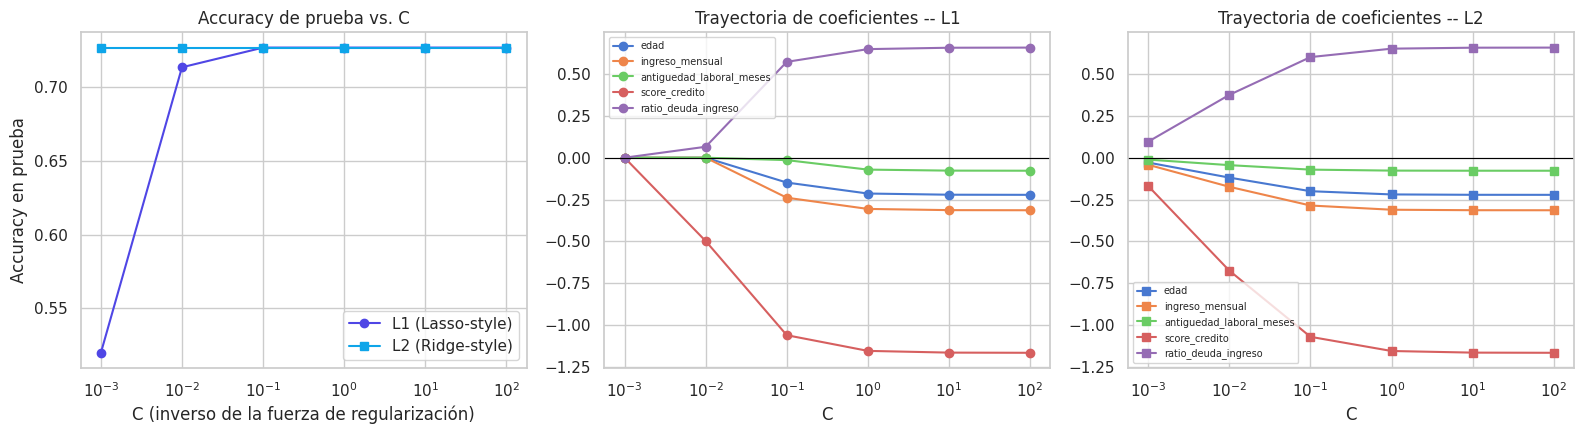

Numero de coeficientes exactamente en cero por valor de C (L1):
  C=0.001: 5 coeficientes en cero
  C=0.01: 3 coeficientes en cero
  C=0.1: 0 coeficientes en cero
  C=1: 0 coeficientes en cero
  C=10: 0 coeficientes en cero
  C=100: 0 coeficientes en cero


In [8]:
Cs = [0.001, 0.01, 0.1, 1, 10, 100]
resultados_l1, resultados_l2 = [], []
coefs_l1, coefs_l2 = [], []

for C in Cs:
    m_l1 = LogisticRegression(penalty="l1", C=C, solver="liblinear", max_iter=1000, random_state=42).fit(Xtr_esc, ytr)
    m_l2 = LogisticRegression(penalty="l2", C=C, solver="liblinear", max_iter=1000, random_state=42).fit(Xtr_esc, ytr)
    resultados_l1.append(accuracy_score(yte, m_l1.predict(Xte_esc)))
    resultados_l2.append(accuracy_score(yte, m_l2.predict(Xte_esc)))
    coefs_l1.append(m_l1.coef_[0])
    coefs_l2.append(m_l2.coef_[0])

coefs_l1 = np.array(coefs_l1)
coefs_l2 = np.array(coefs_l2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(Cs, resultados_l1, marker="o", label="L1 (Lasso-style)", color="#4f46e5")
axes[0].plot(Cs, resultados_l2, marker="s", label="L2 (Ridge-style)", color="#0ea5e9")
axes[0].set_xscale("log")
axes[0].set_xlabel("C (inverso de la fuerza de regularización)")
axes[0].set_ylabel("Accuracy en prueba")
axes[0].set_title("Accuracy de prueba vs. C")
axes[0].legend()

for j, f in enumerate(feat_cols_cred):
    axes[1].plot(Cs, coefs_l1[:, j], marker="o", label=f)
axes[1].set_xscale("log")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("C")
axes[1].set_title("Trayectoria de coeficientes -- L1")
axes[1].legend(fontsize=7)

for j, f in enumerate(feat_cols_cred):
    axes[2].plot(Cs, coefs_l2[:, j], marker="s", label=f)
axes[2].set_xscale("log")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_xlabel("C")
axes[2].set_title("Trayectoria de coeficientes -- L2")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

print("Numero de coeficientes exactamente en cero por valor de C (L1):")
for C, c in zip(Cs, coefs_l1):
    print(f"  C={C}: {int((np.abs(c) < 1e-8).sum())} coeficientes en cero")

**Lectura:** el panel de trayectorias hace visible la diferencia cualitativa entre ambas penalizaciones. Con **L1**, a `C=0.001` (regularización muy fuerte) los **5 coeficientes son exactamente cero** (el modelo colapsa a predecir la clase mayoritaria, accuracy≈0.52); a `C=0.01` ya sobreviven 2 de 5 (`score_credito` y `ratio_deuda_ingreso` — exactamente las dos variables más correlacionadas identificadas en la Sección 6), con los otros 3 todavía en cero; desde `C=0.1` en adelante los 5 coeficientes son distintos de cero y la accuracy se estabiliza en 0.7267. Con **L2**, en cambio, ningún coeficiente llega nunca a cero exacto — incluso en `C=0.001` los 5 coeficientes son pequeños pero no nulos — y la accuracy se mantiene notablemente estable (0.7267) en casi todo el rango de `C`, porque L2 nunca elimina información, solo la atenúa. En la práctica, L1 es preferible cuando se sospecha que varias variables son irrelevantes y se busca un modelo más simple e interpretable; L2 cuando se cree que todas las variables aportan algo y se prioriza estabilidad.

---
## 8. Aplicación a Datos Desbalanceados: `transacciones_fraude.csv` ⚠️

`es_fraude` es la variable objetivo más desbalanceada del curso: solo 60 de 4060 transacciones son fraudulentas (1.48%, Cuaderno 00). Se ajusta el mismo flujo — escalar, dividir estratificado, `LogisticRegression` — sobre las tres variables disponibles (`monto_transaccion`, `tiempo_respuesta_ms`, `intentos_previos`).

In [9]:
feat_fraude = ["monto_transaccion", "tiempo_respuesta_ms", "intentos_previos"]
X_fraude = fraude[feat_fraude]
y_fraude = fraude["es_fraude"]

Xtr_f, Xte_f, ytr_f, yte_f = train_test_split(X_fraude, y_fraude, test_size=0.25, random_state=42, stratify=y_fraude)
scaler_f = StandardScaler().fit(Xtr_f)
Xtr_f_esc = scaler_f.transform(Xtr_f)
Xte_f_esc = scaler_f.transform(Xte_f)

clf_fraude = LogisticRegression(max_iter=1000, random_state=42).fit(Xtr_f_esc, ytr_f)
pred_fraude = clf_fraude.predict(Xte_f_esc)

acc_fraude = accuracy_score(yte_f, pred_fraude)
baseline_acc = 1 - yte_f.mean()

print(f"Accuracy del modelo sobre el conjunto de prueba: {acc_fraude:.4f}")
print(f"Accuracy de un clasificador trivial que siempre predice 'no fraude': {baseline_acc:.4f}")
print(f"\nMatriz de confusion:\n{confusion_matrix(yte_f, pred_fraude)}")

Accuracy del modelo sobre el conjunto de prueba: 1.0000
Accuracy de un clasificador trivial que siempre predice 'no fraude': 0.9852

Matriz de confusion:
[[1000    0]
 [   0   15]]


**Lectura — nota honesta sobre accuracy en clases desbalanceadas:** en este dataset en particular, el modelo logra una accuracy de **100%** sobre las 1015 transacciones de prueba, detectando correctamente las 15 fraudulentas sin ningún falso positivo — un resultado excelente, explicado por lo separables que son las clases aquí (las tres variables tienen correlaciones de 0.83 a 0.93 con `es_fraude`, según el Cuaderno 00). Pero eso **no significa que la accuracy sea, en general, una métrica confiable** para datos desbalanceados: un clasificador trivial que siempre prediga "no fraude" ya alcanzaría **98.52%** de accuracy sin detectar ni un solo caso de fraude. Es decir, una accuracy alta nunca es, por sí sola, evidencia de que un modelo esté detectando bien la clase minoritaria — hay que mirar métricas específicas por clase (precisión, recall, F1, ROC-AUC), que se desarrollan en profundidad en el **Cuaderno 04**.

---
## 9. Ejercicio Práctico Guiado: Regularización L1 sobre `transacciones_fraude.csv` 📝

**Contexto:** en la Sección 7 se vio que, sobre `clientes_credito.csv`, la penalización L1 anula progresivamente coeficientes a medida que `C` disminuye. Vas a repetir ese barrido, esta vez sobre las variables escaladas de `transacciones_fraude.csv` (`Xtr_f_esc`, `ytr_f`, `Xte_f_esc`, `yte_f`, ya definidas en la Sección 8), para identificar a partir de qué valor de `C` el modelo deja de anular coeficientes — y qué le pasa a la accuracy en ese punto.

**Tu misión:**
1. Define `Cs_ejercicio = [0.001, 0.01, 0.1, 1, 10, 100]`.
2. Para cada `C`, entrena `LogisticRegression(penalty="l1", C=C, solver="liblinear", max_iter=1000, random_state=42)` sobre `Xtr_f_esc`, `ytr_f`.
3. Calcula la accuracy sobre `Xte_f_esc`, `yte_f`, y cuenta cuántos coeficientes son exactamente cero (`abs(coef) < 1e-8`).
4. Guarda los resultados en una lista de diccionarios y conviértela en un DataFrame.
5. Identifica el primer valor de `C` (de menor a mayor) en el que **ningún** coeficiente queda en cero.

In [10]:
### TU CÓDIGO AQUÍ ###
# 1. Define la lista de valores de C
Cs_ejercicio = None

# 2-3. Para cada C, entrena el modelo L1 y calcula accuracy + coeficientes en cero
resultados_ejercicio = []

# for C in Cs_ejercicio:
#     m = None
#     acc = None
#     n_zero = None
#     resultados_ejercicio.append({"C": C, "accuracy_test": acc, "coeficientes_en_cero": n_zero})

# 4. Convierte a DataFrame
df_ejercicio = None
print(df_ejercicio)

# 5. Encuentra el primer C sin coeficientes en cero
primer_C_completo = None
print("Primer C sin coeficientes en cero:", primer_C_completo)

None
Primer C sin coeficientes en cero: None


<details>
<summary>💡 Ver solución propuesta</summary>

```python
Cs_ejercicio = [0.001, 0.01, 0.1, 1, 10, 100]
resultados_ejercicio = []

for C in Cs_ejercicio:
    m = LogisticRegression(penalty="l1", C=C, solver="liblinear", max_iter=1000, random_state=42).fit(Xtr_f_esc, ytr_f)
    acc = accuracy_score(yte_f, m.predict(Xte_f_esc))
    n_zero = int((np.abs(m.coef_[0]) < 1e-8).sum())
    resultados_ejercicio.append({"C": C, "accuracy_test": acc, "coeficientes_en_cero": n_zero})

df_ejercicio = pd.DataFrame(resultados_ejercicio)
print(df_ejercicio)

primer_C_completo = df_ejercicio.loc[df_ejercicio["coeficientes_en_cero"] == 0, "C"].min()
print("Primer C sin coeficientes en cero:", primer_C_completo)
```

</details>

---
## 10. Resumen Ejecutivo del Cuaderno 02 📌

1. **La regresión lineal no es apta para un objetivo binario:** sobre `clientes_credito.csv`, `LinearRegression` produjo 11 predicciones negativas y 5 mayores a 1 (de 1200) — valores sin interpretación como probabilidad. La solución no es forzar el rango después, sino modelar una cantidad que sí es naturalmente lineal: el **logit** $\log(p/(1-p))$.
2. **La sigmoide $\sigma(z)=1/(1+e^{-z})$ es la inversa del logit:** transforma cualquier combinación lineal $z=w^Tx+b$ en una probabilidad válida en $(0,1)$, con $\sigma(0)=0.5$ como punto de simetría — de ahí el umbral de decisión por defecto.
3. **`LogisticRegression` alcanzó 72.67% de accuracy** con las 5 variables de `clientes_credito.csv` (75.00% con solo `score_credito` y `ratio_deuda_ingreso`), comparable al 71-71.33% de k-NN sobre las mismas variables (Cuaderno 01) — evidencia de que la frontera real es, en gran medida, lineal.
4. **Los coeficientes se interpretan como odds ratios ($e^{w_j}$), no como efectos directos:** un aumento de una desviación estándar en `score_credito` multiplica las odds de default por 0.315 (las reduce 68.5%); el mismo aumento en `ratio_deuda_ingreso` las multiplica por 1.92 (casi las duplica).
5. **L1 anula coeficientes progresivamente al disminuir `C`** (selección automática de variables: a `C=0.01` solo sobreviven `score_credito` y `ratio_deuda_ingreso`), mientras que **L2 los contrae suavemente sin anularlos nunca** — con `C` como inverso de la fuerza de regularización.
6. **La accuracy es engañosa en clases desbalanceadas:** el modelo sobre `transacciones_fraude.csv` (1.48% de fraude) logró 100% de accuracy en este caso, pero un clasificador trivial que siempre prediga "no fraude" ya obtendría 98.52% — la evaluación rigurosa de clasificadores desbalanceados requiere las métricas del **Cuaderno 04**.
7. **Siguiente paso:** el **Cuaderno 03** retoma la regularización L1/L2 (y agrega ElasticNet) para el caso de **regresión** sobre `inmuebles_precios.csv`, junto con regresión polinomial y sus propios riesgos de sobreajuste.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Clasificación y Regresión</i>
  </p>
</div>